# Lasso Regession Model

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta)
df.isnull().sum()

om                  0
yr                  0
mo                  0
dy                  0
date                0
time                0
tz                  0
datetime_utc        0
st                  0
stf                 0
mag               756
inj                 0
fat                 0
loss            27170
slat                0
slon                0
elat                0
elon                0
len                 0
wid                 0
ns                  0
sn                  0
f1                  0
f2                  0
f3                  0
f4                  0
fc                  0
dtype: int64

In [3]:
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
# Imputar los valores NaN con la media de la columna 'mag'
df['mag'] = df['mag'].fillna(df['mag'].mean())

In [4]:
df.shape

(68693, 27)

## Implementación Regresión Lasso L1

In [15]:
import numpy as np

In [26]:
# Definir X y y (asegúrate de que ya tienes estas variables previamente definidas)
X = df[['mag', 'slat', 'slon', 'elat', 'elon', 'len', 'wid','f1', 'f2', 'f3', 'f4','loss']]
y = df['inj']

# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y ajustar el modelo de regresión lineal
lr = LinearRegression().fit(X_train, y_train)

In [27]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

# Ver los coeficientes de cada variable en el modelo
coeficientes = pd.Series(lasso.coef_, index=X_train.columns)

# Ver el intercepto del modelo
intercepto = lasso.intercept_

# Mostrar los coeficientes y el intercepto
print("Coeficientes del modelo Lasso:")
print(coeficientes)

print("\nIntercepto del modelo Lasso:")
print(intercepto)

Training set score: 0.24
Test set score: 0.33
Number of features used: 9
Coeficientes del modelo Lasso:
mag     3.947769e-01
slat   -0.000000e+00
slon    8.440884e-03
elat   -0.000000e+00
elon    1.130322e-02
len     3.256648e-01
wid     5.826324e-03
f1     -2.680782e-04
f2     -2.472932e-03
f3      5.332251e-03
f4     -0.000000e+00
loss    2.940895e-07
dtype: float64

Intercepto del modelo Lasso:
0.2772814639970196


In [28]:
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso001.coef_ != 0)))

# Ver los coeficientes de cada variable en el modelo
coeficientes = pd.Series(lasso001.coef_, index=X_train.columns)

# Ver el intercepto del modelo
intercepto = lasso001.intercept_

# Mostrar los coeficientes y el intercepto
print("Coeficientes del modelo lasso001:")
print(coeficientes)

print("\nIntercepto del modelo lasso001:")
print(intercepto)

Training set score: 0.25
Test set score: 0.33
Number of features used: 12
Coeficientes del modelo lasso001:
mag     2.085277e+00
slat   -3.496292e-02
slon    1.487790e-03
elat    6.610278e-03
elon    1.078612e-02
len     2.824790e-01
wid     3.351305e-03
f1     -6.745159e-04
f2     -7.067784e-03
f3      1.123411e-02
f4     -2.222175e-03
loss    2.913002e-07
dtype: float64

Intercepto del modelo lasso001:
-0.07284336963033344


In [29]:
lasso00001 = Lasso(alpha=0.0001, max_iter=100000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso00001.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso00001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso00001.coef_ != 0)))

# Ver los coeficientes de cada variable en el modelo
coeficientes = pd.Series(lasso00001.coef_, index=X_train.columns)

# Ver el intercepto del modelo
intercepto = lasso00001.intercept_

# Mostrar los coeficientes y el intercepto
print("Coeficientes del modelo lasso00001:")
print(coeficientes)

print("\nIntercepto del modelo lasso00001:")
print(intercepto)

Training set score: 0.25
Test set score: 0.33
Number of features used: 12
Coeficientes del modelo lasso00001:
mag     2.102171e+00
slat   -3.672660e-02
slon    8.712739e-04
elat    8.898865e-03
elon    1.166160e-02
len     2.820274e-01
wid     3.326751e-03
f1     -6.829800e-04
f2     -7.113115e-03
f3      1.131723e-02
f4     -2.355945e-03
loss    2.912714e-07
dtype: float64

Intercepto del modelo lasso00001:
-0.07503666609775572


In [10]:
from sklearn.linear_model import Ridge

In [30]:
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge01.score(X_test, y_test)))

Training set score: 0.25
Test set score: 0.33


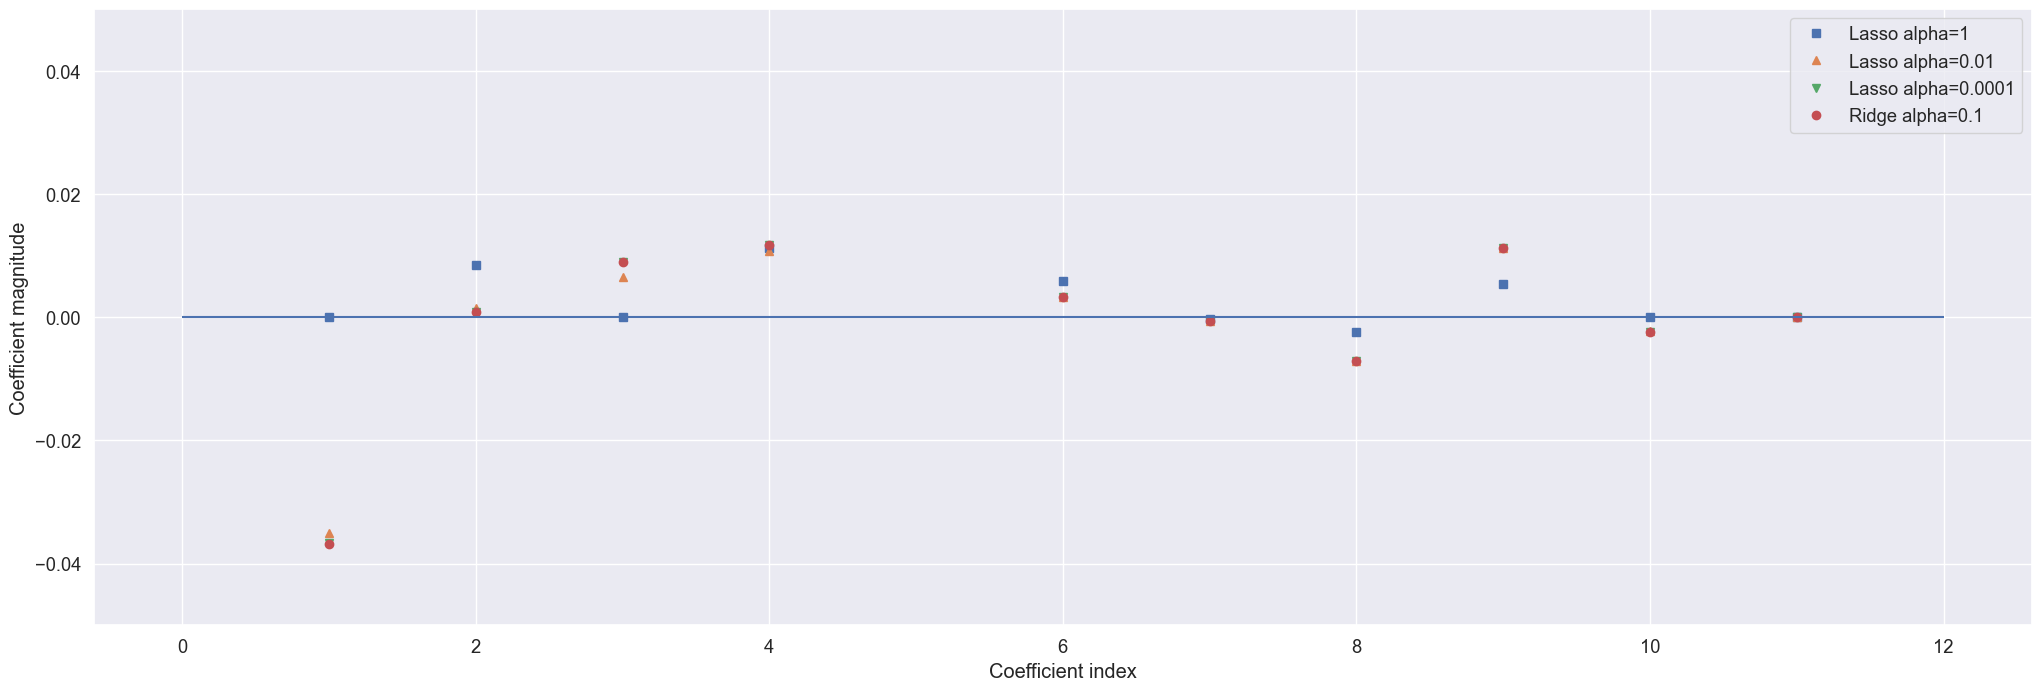

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
sns.set(font_scale=1.2)

# Establecer el tamaño de la fuente
sns.set(font_scale=1.2)

# Crear la figura
plt.figure(figsize=(25, 8))

# Graficar los coeficientes para diferentes modelos
plt.plot(lasso.coef_, 's', label="Lasso alpha=1")  # Tamaño de marcador aumentado
plt.plot(lasso001.coef_, '^', label="Lasso alpha=0.01")
plt.plot(lasso00001.coef_, 'v', label="Lasso alpha=0.0001")
plt.plot(ridge01.coef_, 'o', label="Ridge alpha=0.1")

# Ajustar las etiquetas y las líneas de referencia
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

# Línea horizontal en y = 0 para visualización
plt.hlines(0, 0, len(lr.coef_))

# Ajustar el límite del eje Y
plt.ylim(-0e3, 0e3)  # Ajusta según el rango de los coeficientes (puedes modificar esto)

# Cambiar el eje Y a una escala logarítmica si la disparidad es muy grande
# plt.yscale('symlog')  # Descomenta esta línea si quieres usar una escala logarítmica

# Agregar la leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

## Metricas Regesión Lasso y Ridge con Pipe Line y Grid_Search

In [ ]:
pip install statsmodels

In [35]:
# ------------------------
# Paso 1: Importar los paquetes necesarios
# ------------------------
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from joblib import load
from time import time  # Agregar importación de time

# ------------------------
# Paso 2: Cargar los modelos entrenados
# ------------------------
# Asegurarse de que los modelos estén cargados
if 'grid_lasso' not in globals() or 'grid_ridge' not in globals():
    grid_lasso = load('grid_lasso.joblib')
    grid_ridge = load('grid_ridge.joblib')

# ------------------------
# Paso 3: Hacer predicciones con los modelos Lasso y Ridge
# ------------------------
# Predicciones con el mejor modelo de Lasso
y_pred_lasso = grid_lasso.best_estimator_.predict(X_test)

# Predicciones con el mejor modelo de Ridge
y_pred_ridge = grid_ridge.best_estimator_.predict(X_test)

# ------------------------
# Paso 4: Calcular las métricas para Lasso
# ------------------------
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

# Ljung-Box p-value para Lasso
lb_test_lasso = acorr_ljungbox(y_test - y_pred_lasso, lags=[10])
lb_p_value_lasso = lb_test_lasso['lb_pvalue'].iloc[0]  # Accede al valor p del primer lag (lag 10)

# Jarque-Bera p-value para Lasso
jb_p_value_lasso = jarque_bera(y_test - y_pred_lasso)[1]

# ------------------------
# Paso 5: Calcular las métricas para Ridge
# ------------------------
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# Ljung-Box p-value para Ridge
lb_test_ridge = acorr_ljungbox(y_test - y_pred_ridge, lags=[10])
lb_p_value_ridge = lb_test_ridge['lb_pvalue'].iloc[0]  # Accede al valor p del primer lag (lag 10)

# Jarque-Bera p-value para Ridge
jb_p_value_ridge = jarque_bera(y_test - y_pred_ridge)[1]

# ------------------------
# Paso 6: Crear DataFrames con los resultados
# ------------------------
# Resultados para Lasso
resultados_lasso = pd.DataFrame({
    'Modelo': ['Lasso'],
    'MAPE': [f"{mape_lasso:.2f}"],
    'RMSE': [f"{rmse_lasso:.2f}"],
    'R Cuadrado': [f"{r2_lasso:.2f}"],
    'Ljung-Box Test p-value': [f"{lb_p_value_lasso:.4f}"],
    'Jarque-Bera p-value': [f"{jb_p_value_lasso:.4f}"],
    'CPU time (s)': ["N/A"]  # Tiempo de entrenamiento no disponible
})

# Resultados para Ridge
resultados_ridge = pd.DataFrame({
    'Modelo': ['Ridge'],
    'MAPE': [f"{mape_ridge:.2f}"],
    'RMSE': [f"{rmse_ridge:.2f}"],
    'R Cuadrado': [f"{r2_ridge:.2f}"],
    'Ljung-Box Test p-value': [f"{lb_p_value_ridge:.4f}"],
    'Jarque-Bera p-value': [f"{jb_p_value_ridge:.4f}"],
    'CPU time (s)': ["N/A"]  # Tiempo de entrenamiento no disponible
})

# ------------------------
# Paso 7: Combinar los resultados en un solo DataFrame
# ------------------------
resultados_combinados = pd.concat([resultados_lasso, resultados_ridge], ignore_index=True)

# ------------------------
# Paso 8: Mostrar los resultados
# ------------------------
print("Métricas combinadas para Lasso y Ridge:")
display(resultados_combinados)

Métricas combinadas para Lasso y Ridge:


,Modelo,MAPE,RMSE,R Cuadrado,Ljung-Box Test p-value,Jarque-Bera p-value,CPU time (s)
0,Lasso,8658017849098115.00,18.86,0.33,0.9364,0.0000,N/A
1,Ridge,8943370414620937.00,18.83,0.33,0.9320,0.0000,N/A
